Hier werden die VAriablen in jedem Datensatz untersucht und zum Schluss ein einheitlicher Datensatz erstellt, mit dem ich in den folgenden Schritten arbeiten werde

In [20]:
import sys, mlflow, pandas as pd
import os
from pathlib import Path
from pandas.api.types import is_datetime64_any_dtype as is_datetime
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [21]:

sns.set(style="whitegrid")

BASE_DIR = Path(r"C:\Users\nelid\Documents\Kaggle Competitions\Store Sales Competition\store-sales")
PROCESSED_DIR = BASE_DIR / "data" / "processed"

files_processed = {
    "train": "train_processed.csv",
    "test": "test_processed.csv",
    "stores": "stores_processed.csv",
    "oil": "oil_processed.csv",
    "holidays_events": "holidays_events_processed.csv",
    "transactions": "transactions_processed.csv",
}

dfs = {}
for name, fname in files_processed.items():
    path = PROCESSED_DIR / fname
    df = pd.read_csv(path, parse_dates=["date"]) if "date" in pd.read_csv(path, nrows=1).columns else pd.read_csv(path)
    dfs[name] = df
    print(f"{name}: shape={df.shape}, date dtype={dfs[name]['date'].dtype if 'date' in df.columns else 'no date column'}")

train: shape=(3000888, 6), date dtype=datetime64[ns]
test: shape=(28512, 5), date dtype=datetime64[ns]
stores: shape=(54, 5), date dtype=no date column
oil: shape=(1218, 2), date dtype=datetime64[ns]
holidays_events: shape=(350, 6), date dtype=datetime64[ns]
transactions: shape=(83488, 3), date dtype=datetime64[ns]


In [22]:
# Erstelle Hilfsfunktionen für die Untersuchung von numerischen und kategorialen Variablen

sns.set(style="whitegrid")

def get_num_cat_cols(df, max_unique_for_categorical=30): # Variablen mit über 30 Kategorien gelten als numerisch. Evtl revidieren?
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist() # Wenn Zahlen drin sind, ist das eine numerische Spalte
    # object, category, bool, und int/float mit wenigen Ausprägungen als kategorial
    cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist() # Wenn keine Zahlen - kategorsch
    low_card_num = [
        c for c in num_cols
        if df[c].nunique() <= max_unique_for_categorical and c not in ["sales"]
    ]
    cat_cols = list(dict.fromkeys(cat_cols + low_card_num))  # Duplikate entfernen
    num_cols = [c for c in num_cols if c not in cat_cols]
    return num_cols, cat_cols


In [23]:
# Hilfsfunktion generischer EDA Block pro Datensatz

def quick_overview(df: pd.DataFrame, name: str, target_col: str | None = None):
    print(f"\n===== {name} =====")
    print("Shape:", df.shape)
    display(df.head())
    print("\nInfo:")
    display(df.info())

    # Anzahl unique Werte pro Spalte
    nunique = df.nunique(dropna=False).sort_values(ascending=False)
    nunique_df = nunique.to_frame(name="n_unique")
    nunique_df["dtype"] = df.dtypes[nunique_df.index].astype(str)
    display(nunique_df)

    num_cols, cat_cols = get_num_cat_cols(df)
    print("\nNumerical columns:", num_cols)
    print("Categorical columns:", cat_cols)

    # Numerische Summary
    if num_cols:
        display(df[num_cols].describe().T)

    # Kategoriale Summary (Top-Kategorien)
    for c in cat_cols:
        print(f"\nValue counts for {c}:")
        display(df[c].value_counts(dropna=False).head(20))


In [24]:
# Aufruf der EDA Funktionen für alle Datensätze

quick_overview(dfs["train"], "train", target_col="sales")




===== train =====
Shape: (3000888, 6)


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


None

,n_unique,dtype
id,3000888,int64
sales,379610,float64
date,1684,datetime64[ns]
onpromotion,362,int64
store_nbr,54,int64
family,33,object



Numerical columns: ['id', 'store_nbr', 'sales', 'onpromotion']
Categorical columns: ['family']


,count,mean,std,min,25%,50%,75%,max
id,3000888.0,1.500444e+06,866281.891642,0.0,750221.75,1500443.5,2.250665e+06,3000887.0
store_nbr,3000888.0,2.750000e+01,15.585787,1.0,14.00,27.5,4.100000e+01,54.0
sales,3000888.0,3.577757e+02,1101.997721,0.0,0.00,11.0,1.958473e+02,124717.0
onpromotion,3000888.0,2.602770e+00,12.218882,0.0,0.00,0.0,0.000000e+00,741.0



Value counts for family:


family
AUTOMOTIVE             90936
BABY CARE              90936
BEAUTY                 90936
BEVERAGES              90936
BOOKS                  90936
BREAD/BAKERY           90936
CELEBRATION            90936
CLEANING               90936
DAIRY                  90936
DELI                   90936
EGGS                   90936
FROZEN FOODS           90936
GROCERY I              90936
GROCERY II             90936
HARDWARE               90936
HOME AND KITCHEN I     90936
HOME AND KITCHEN II    90936
HOME APPLIANCES        90936
HOME CARE              90936
LADIESWEAR             90936
Name: count, dtype: int64

In [25]:
quick_overview(dfs["stores"], "stores")



===== stores =====
Shape: (54, 5)


,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   state      54 non-null     object
 3   type       54 non-null     object
 4   cluster    54 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.2+ KB


None

,n_unique,dtype
store_nbr,54,int64
city,22,object
cluster,17,int64
state,16,object
type,5,object


...

state
Pichincha                         19
Guayas                            11
Azuay                              3
Santo Domingo de los Tsachilas     3
Manabi                             3
Los Rios                           2
Cotopaxi                           2
Tungurahua                         2
El Oro                             2
Bolivar                            1
Imbabura                           1
Chimborazo                         1
Pastaza                            1
Santa Elena                        1
Loja                               1
Esmeraldas                         1
Name: count, dtype: int64


Value counts for type:


type
D    18
C    15
A     9
B     8
E     4
Name: count, dtype: int64


Value counts for cluster:


cluster
3     7
10    6
6     6
15    5
13    4
14    4
11    3
4     3
8     3
1     3
2     2
9     2
7     2
12    1
16    1
5     1
17    1
Name: count, dtype: int64

In [26]:
quick_overview(dfs["oil"], "oil")


===== oil =====
Shape: (1218, 2)


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        1218 non-null   datetime64[ns]
 1   dcoilwtico  1175 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 19.2 KB


None

,n_unique,dtype
date,1218,datetime64[ns]
dcoilwtico,999,float64



Numerical columns: ['dcoilwtico']
Categorical columns: []


,count,mean,std,min,25%,50%,75%,max
dcoilwtico,1175.0,67.714366,25.630476,26.19,46.405,53.19,95.66,110.62


In [27]:
quick_overview(dfs["holidays_events"], "holidays_events")


===== holidays_events =====
Shape: (350, 6)


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         350 non-null    datetime64[ns]
 1   type         350 non-null    object        
 2   locale       350 non-null    object        
 3   locale_name  350 non-null    object        
 4   description  350 non-null    object        
 5   transferred  350 non-null    bool          
dtypes: bool(1), datetime64[ns](1), object(4)
memory usage: 14.1+ KB


None

,n_unique,dtype
date,312,datetime64[ns]
description,103,object
locale_name,24,object
type,6,object
locale,3,object
transferred,2,bool


...

locale_name
Ecuador          174
Quito             13
Guaranda          12
Riobamba          12
Latacunga         12
Ambato            12
Guayaquil         11
Cuenca             7
Ibarra             7
Imbabura           6
Cotopaxi           6
Libertad           6
Manta              6
Puyo               6
El Carmen          6
Machala            6
Cayambe            6
Esmeraldas         6
Santo Domingo      6
Quevedo            6
Name: count, dtype: int64


Value counts for description:


description
Carnaval                         10
Fundacion de Ibarra               7
Fundacion de Cuenca               7
Cantonizacion de Libertad         6
Cantonizacion de Riobamba         6
Cantonizacion del Puyo            6
Fundacion de Manta                6
Cantonizacion de Guaranda         6
Provincializacion de Imbabura     6
Fundacion de Machala              6
Cantonizacion de Latacunga        6
Cantonizacion de El Carmen        6
Cantonizacion de Cayambe          6
Fundacion de Esmeraldas           6
Fundacion de Santo Domingo        6
Primer Grito de Independencia     6
Fundacion de Riobamba             6
Fundacion de Ambato               6
Cantonizacion de Quevedo          6
Independencia de Guayaquil        6
Name: count, dtype: int64


Value counts for transferred:


transferred
False    338
True      12
Name: count, dtype: int64

In [28]:
quick_overview(dfs["transactions"], "transactions")


===== transactions =====
Shape: (83488, 3)


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          83488 non-null  datetime64[ns]
 1   store_nbr     83488 non-null  int64         
 2   transactions  83488 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 1.9 MB


None

,n_unique,dtype
transactions,4993,int64
date,1682,datetime64[ns]
store_nbr,54,int64



Numerical columns: ['store_nbr', 'transactions']
Categorical columns: []


,count,mean,std,min,25%,50%,75%,max
store_nbr,83488.0,26.939237,15.608204,1.0,13.0,27.0,40.0,54.0
transactions,83488.0,1694.602158,963.286644,5.0,1046.0,1393.0,2079.0,8359.0


In [29]:
# Auffüllen der fehlenden Ölpreis im oil Datensatz:

# Zuerst Serie sortieren und Index setzen
oil = dfs["oil"].sort_values("date").reset_index(drop=True)
oil.set_index("date", inplace=True)


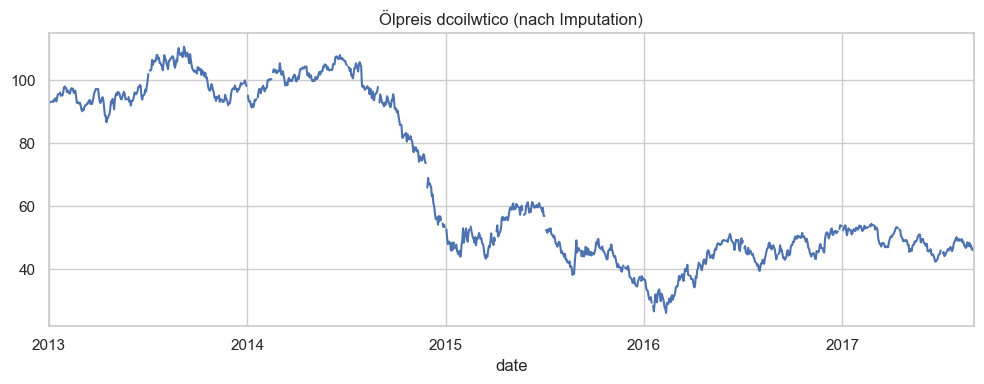

In [30]:
# Serie vor dem Auffüllen


oil["dcoilwtico"].plot(figsize=(10, 4))
plt.title("Ölpreis dcoilwtico (nach Imputation)")
plt.tight_layout()
plt.show()


In [31]:
# Vorwärts-Auffüllung und danach für den Anfang der Serie rückwärts-Auffüllung der fehlenden Werte, um die homogenität der Reihe zu erhalten:
oil["dcoilwtico"] = (
    oil["dcoilwtico"]
    .ffill()   # forward fill
    .bfill()   # backward fill
)


In [32]:
oil.describe()

,dcoilwtico
count,1218.000000
mean,67.692159
std,25.629744
min,26.190000
25%,46.422500
50%,53.200000
75%,95.685000
max,110.620000


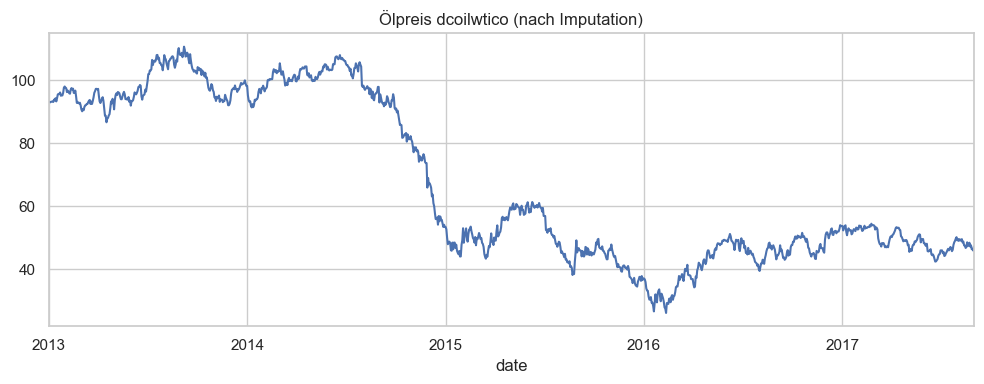

In [33]:
# Visuelle Kontrolle:

oil["dcoilwtico"].plot(figsize=(10, 4))
plt.title("Ölpreis dcoilwtico (nach Imputation)")
plt.tight_layout()
plt.show()


In [35]:
# Zurückschreiben in den Arbeits-Datensatz für Ölpreise
oil_reset = oil.reset_index()  # date wieder als Spalte
dfs["oil"] = oil_reset


In [36]:
# Aufgefüllte Datei abspeichern
PROCESSED_DIR = BASE_DIR / "data" / "processed"
dfs["oil"].to_csv(PROCESSED_DIR / "oil_processed.csv", index=False)
